# Clinical Branch Implementation
## MLP for Clinical Metadata Processing

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load and Explore Clinical Data

In [2]:
# Load clinical dataset
csv_path = "/Users/shubhbhateja/College/minor_project/NeoJaundice/chd_jaundice_published_2.csv"
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (2235, 8)

Columns: ['patient_id', 'image_idx', 'gender', 'gestational_age', 'age(day)', 'weight', 'blood(mg/dL)', 'Treatment']

First few rows:
   patient_id   image_idx gender  gestational_age  age(day)  weight  \
0           3  0003-1.jpg      F               40       5.2    3280   
1           3  0003-2.jpg      F               40       5.2    3280   
2           3  0003-3.jpg      F               40       5.2    3280   
3          35  0035-1.jpg      M               39       8.7    3760   
4          35  0035-2.jpg      M               39       8.7    3760   

   blood(mg/dL)  Treatment  
0           3.9          0  
1           3.9          0  
2           3.9          0  
3          12.2          0  
4          12.2          0  

Data types:
patient_id           int64
image_idx           object
gender              object
gestational_age      int64
age(day)           float64
weight               int64
blood(mg/dL)       float64
Treatment            int64
dtype: obj

## Step 2: Feature Selection and Preprocessing

In [3]:
def select_clinical_features(df):
    """
    Select relevant clinical features for neonatal jaundice prediction
    Common features: Weight, Gestational Age, Postnatal Age, Gender, etc.
    """
    
    # Define potential clinical feature columns
    potential_features = [
        'weight', 'Weight', 'birth_weight', 'Weight(g)',
        'gestational_age', 'GA', 'gestational_age_weeks', 'Gestational_Age',
        'postnatal_age', 'age', 'Age', 'postnatal_age_hours', 'Age(h)',
        'gender', 'Gender', 'sex', 'Sex',
        'delivery_mode', 'delivery', 'Delivery_Mode',
        'feeding_type', 'feeding', 'Feeding_Type',
        'maternal_age', 'mother_age', 'Maternal_Age'
    ]
    
    # Find existing features
    available_features = []
    feature_mapping = {}
    
    for potential in potential_features:
        if potential in df.columns:
            available_features.append(potential)
            feature_mapping[potential] = potential
    
    print("Available clinical features:")
    for feature in available_features:
        print(f"- {feature}: {df[feature].dtype}")
    
    return available_features, feature_mapping

clinical_features, feature_map = select_clinical_features(df)

Available clinical features:
- weight: int64
- gestational_age: int64
- gender: object


In [4]:
def preprocess_clinical_data(df, features):
    """
    Preprocess clinical features: handle missing values, encode categoricals, normalize
    """
    
    # Create a copy for processing
    processed_df = df[features].copy()
    
    # Handle missing values
    print("Handling missing values...")
    for col in processed_df.columns:
        if processed_df[col].dtype in ['object', 'string']:
            # Fill categorical missing values with mode
            processed_df[col] = processed_df[col].fillna(processed_df[col].mode().iloc[0] if not processed_df[col].mode().empty else 'Unknown')
        else:
            # Fill numerical missing values with median
            processed_df[col] = processed_df[col].fillna(processed_df[col].median())
    
    # Encode categorical variables
    label_encoders = {}
    encoded_features = []
    
    for col in processed_df.columns:
        if processed_df[col].dtype == 'object':
            print(f"Encoding categorical feature: {col}")
            le = LabelEncoder()
            processed_df[col] = le.fit_transform(processed_df[col].astype(str))
            label_encoders[col] = le
            encoded_features.append(col)
    
    print(f"Encoded features: {encoded_features}")
    
    return processed_df, label_encoders

# Preprocess clinical features
if clinical_features:
    clinical_data, encoders = preprocess_clinical_data(df, clinical_features)
    print("\nProcessed clinical data shape:", clinical_data.shape)
    print("\nProcessed data sample:")
    print(clinical_data.head())
else:
    print("No clinical features found for processing.")

Handling missing values...
Encoding categorical feature: gender
Encoded features: ['gender']

Processed clinical data shape: (2235, 3)

Processed data sample:
   weight  gestational_age  gender
0    3280               40       0
1    3280               40       0
2    3280               40       0
3    3760               39       1
4    3760               39       1


## Step 3: Feature Normalization (Min-Max / Z-Score Scaling)

In [5]:
def normalize_clinical_features(data, method='minmax'):
    """
    Normalize clinical features using Min-Max or Z-score scaling
    """
    if method == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        print("Using Min-Max scaling (0-1 range)")
    else:  # zscore
        scaler = StandardScaler()
        print("Using Z-score scaling (mean=0, std=1)")
    
    normalized_data = scaler.fit_transform(data)
    
    print(f"Original data shape: {data.shape}")
    print(f"Normalized data shape: {normalized_data.shape}")
    print(f"Normalized data range: [{normalized_data.min():.3f}, {normalized_data.max():.3f}]")
    
    return normalized_data, scaler

# Normalize features
if clinical_features:
    X_clinical, clinical_scaler = normalize_clinical_features(clinical_data, method='minmax')
    
    # Get target variable
    target_cols = ['blood(mg/dL)', 'TSB', 'bilirubin', 'Bilirubin']
    target_col = None
    
    for col in target_cols:
        if col in df.columns:
            target_col = col
            break
    
    if target_col:
        y_clinical = df[target_col].values
        print(f"Target variable: {target_col}")
        print(f"Target shape: {y_clinical.shape}")
        print(f"Target range: [{y_clinical.min():.2f}, {y_clinical.max():.2f}]")
    else:
        print("Warning: No target variable found")
        y_clinical = np.zeros(len(clinical_data))

Using Min-Max scaling (0-1 range)
Original data shape: (2235, 3)
Normalized data shape: (2235, 3)
Normalized data range: [0.000, 1.000]
Target variable: blood(mg/dL)
Target shape: (2235,)
Target range: [0.00, 25.70]


## Step 4: Build Clinical MLP Branch

In [6]:
def build_clinical_mlp(input_dim, embedding_dim=64):
    """
    Build MLP for clinical features processing
    Architecture: Dense -> ReLU -> Dropout -> Dense -> ReLU -> Dropout -> Embedding
    """
    
    inputs = tf.keras.Input(shape=(input_dim,), name='clinical_input')
    
    # Layer 1: Dense -> ReLU -> Dropout
    x = tf.keras.layers.Dense(128, activation='relu', name='clinical_dense_1')(inputs)
    x = tf.keras.layers.Dropout(0.3, name='clinical_dropout_1')(x)
    
    # Layer 2: Dense -> ReLU -> Dropout  
    x = tf.keras.layers.Dense(64, activation='relu', name='clinical_dense_2')(x)
    x = tf.keras.layers.Dropout(0.3, name='clinical_dropout_2')(x)
    
    # Clinical Embedding Vector
    clinical_embedding = tf.keras.layers.Dense(embedding_dim, activation='relu', name='clinical_embedding')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=clinical_embedding, name='clinical_branch')
    
    return model

# Build clinical model
if clinical_features:
    clinical_model = build_clinical_mlp(X_clinical.shape[1])
    clinical_model.summary()
    
    # Visualize model architecture
    tf.keras.utils.plot_model(clinical_model, show_shapes=True, show_layer_names=True)

Model: "clinical_branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ clinical_input (InputLayer)     │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_dense_1 (Dense)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_dropout_1 (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_dense_2 (Dense)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_dropout_2 (Dropout)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_embedding (Dense)      │ (None, 64)             │         4,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,928 (50.50 KB)

 Trainable params: 12,928 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## Step 5: Train and Test Clinical Branch

In [7]:
# Create standalone clinical model for testing
def build_standalone_clinical_model(input_dim):
    """
    Build standalone clinical model for testing purposes
    """
    inputs = tf.keras.Input(shape=(input_dim,))
    
    x = tf.keras.layers.Dense(128, activation='relu')(inputs)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    
    # Output layer for TSB prediction
    output = tf.keras.layers.Dense(1, name='tsb_prediction')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=output)
    
    return model

if clinical_features and target_col:
    # Split data
    X_train_clin, X_test_clin, y_train_clin, y_test_clin = train_test_split(
        X_clinical, y_clinical, test_size=0.2, random_state=42
    )
    
    print(f"Training set: {X_train_clin.shape}, {y_train_clin.shape}")
    print(f"Test set: {X_test_clin.shape}, {y_test_clin.shape}")
    
    # Build and compile model
    standalone_clinical = build_standalone_clinical_model(X_clinical.shape[1])
    
    standalone_clinical.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
        loss='mse',
        metrics=['mae']
    )
    
    standalone_clinical.summary()

Training set: (1788, 3), (1788,)
Test set: (447, 3), (447,)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tsb_prediction (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train clinical model
if clinical_features and target_col:
    early_stop = tf.keras.callbacks.EarlyStopping(
        patience=15,
        restore_best_weights=True,
        monitor='val_loss'
    )
    
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6
    )
    
    print("Training clinical model...")
    history = standalone_clinical.fit(
        X_train_clin, y_train_clin,
        validation_split=0.1,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    # Evaluate model
    test_loss, test_mae = standalone_clinical.evaluate(X_test_clin, y_test_clin)
    print(f"\nTest Results:")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test MSE: {test_loss:.4f}")
    
    # Calculate R²
    y_pred = standalone_clinical.predict(X_test_clin)
    r2 = r2_score(y_test_clin, y_pred)
    print(f"Test R²: {r2:.4f}")

Training clinical model...
Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 130.3668 - mae: 10.1204 - val_loss: 33.1531 - val_mae: 4.6943 - learning_rate: 0.0010
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - loss: 31.5978 - mae: 4.5876 - val_loss: 28.6239 - val_mae: 4.3817 - learning_rate: 0.0010
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 27.3122 - mae: 4.2762 - val_loss: 28.6115 - val_mae: 4.3725 - learning_rate: 0.0010
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - loss: 27.1244 - mae: 4.2627 - val_loss: 28.6272 - val_mae: 4.3705 - learning_rate: 0.0010
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - loss: 29.2262 - mae: 4.5114 - val_loss: 28.5879 - val_mae: 4.3689 - learning_rate: 0.0010
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 27.5959 - mae: 4.3965 - val_loss: 28.8765 - val_mae: 4.3912 - learning_rate: 0.0010
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - loss: 27.5371 - mae: 4.4276 - val_loss: 28.4825 

## Step 6: Visualize Results

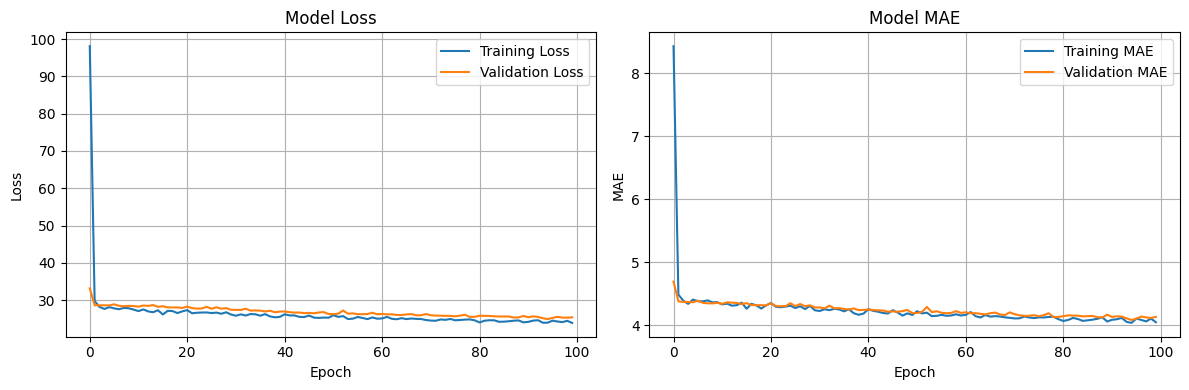

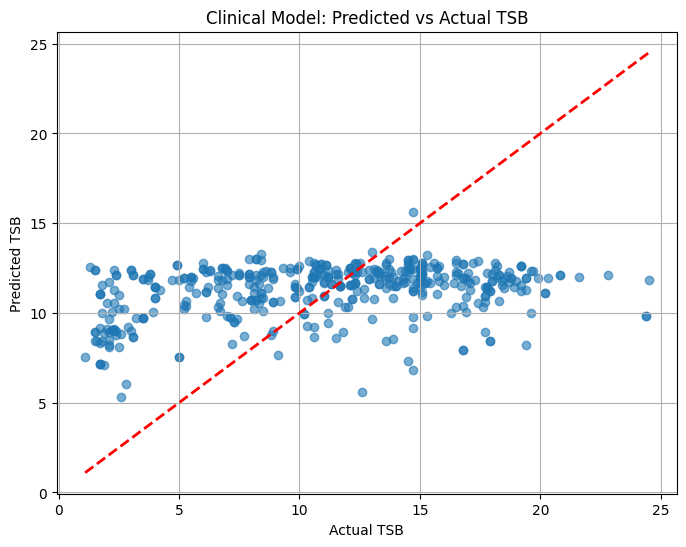

In [9]:
# Plot training history
if 'history' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # MAE plot
    ax2.plot(history.history['mae'], label='Training MAE')
    ax2.plot(history.history['val_mae'], label='Validation MAE')
    ax2.set_title('Model MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot predictions vs actual
if 'y_pred' in locals():
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_clin, y_pred.flatten(), alpha=0.6)
    plt.plot([y_test_clin.min(), y_test_clin.max()], [y_test_clin.min(), y_test_clin.max()], 'r--', lw=2)
    plt.xlabel('Actual TSB')
    plt.ylabel('Predicted TSB')
    plt.title('Clinical Model: Predicted vs Actual TSB')
    plt.grid(True)
    plt.show()

## Step 7: Save Clinical Branch for Fusion

In [10]:
# Save trained clinical branch and preprocessing components
if clinical_features:
    # Save the clinical embedding model (for fusion)
    clinical_model.save('/Users/shubhbhateja/College/minor_project/development/clinical_branch_model.h5')
    
    # Save preprocessing components
    import pickle
    
    preprocessing_components = {
        'scaler': clinical_scaler,
        'encoders': encoders if 'encoders' in locals() else {},
        'feature_names': clinical_features,
        'target_column': target_col
    }
    
    with open('/Users/shubhbhateja/College/minor_project/development/clinical_preprocessing.pkl', 'wb') as f:
        pickle.dump(preprocessing_components, f)
    
    print("Clinical branch and preprocessing components saved!")
    print("Files saved:")
    print("- clinical_branch_model.h5")
    print("- clinical_preprocessing.pkl")

Clinical branch and preprocessing components saved!
Files saved:
- clinical_branch_model.h5
- clinical_preprocessing.pkl
